In [ ]:
# ============================================================
# CELL 0: ติดตั้ง Library
# ============================================================
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn tensorflow -q

In [ ]:
# ============================================================
# CELL 1: Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("✅ Import libraries สำเร็จ")
print(f"   TensorFlow version: {tf.__version__}")

✅ Import libraries สำเร็จ
   TensorFlow version: 2.19.0


In [ ]:
# ============================================================
# CELL 2: โหลด Dataset
# (อัพโหลดไฟล์ CSV เข้า Colab ก่อนรัน cell นี้)
# ============================================================
df1 = pd.read_csv('used_cars.csv')
df2 = pd.read_csv('car_price_prediction.csv')

print("📦 Dataset 1 — used_cars.csv")
print(f"   Shape: {df1.shape}")
print(f"   Columns: {list(df1.columns)}")

print()

print("📦 Dataset 2 — car_price_prediction.csv")
print(f"   Shape: {df2.shape}")
print(f"   Columns: {list(df2.columns)}")

📦 Dataset 1 — used_cars.csv
   Shape: (4009, 12)
   Columns: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']

📦 Dataset 2 — car_price_prediction.csv
   Shape: (19237, 18)
   Columns: ['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage', 'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'Airbags']


In [ ]:
# ============================================================
# CELL 3: Exploratory Data Analysis (EDA)
# ============================================================
print("=" * 50)
print("EDA — Dataset 1: used_cars.csv")
print("=" * 50)
print(df1.info())
print("\nMissing values:")
print(df1.isnull().sum())
print("\nตัวอย่างข้อมูล:")
display(df1.head())

print()

print("=" * 50)
print("EDA — Dataset 2: car_price_prediction.csv")
print("=" * 50)
print(df2.info())
print("\nMissing values (raw — '-' ยังไม่นับ):")
print(df2.isnull().sum())
print("\nตัวอย่างข้อมูล:")
display(df2.head())

EDA — Dataset 1: used_cars.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB
None

Missing values:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"



EDA — Dataset 2: car_price_prediction.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 1

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [ ]:
# ============================================================
# CELL 4: Data Preparation — Dataset 1 (used_cars.csv)
# ============================================================
df1_clean = df1.copy()

# 4.1 แปลง price: "$10,300" → float
df1_clean['price'] = (df1_clean['price']
                      .str.replace('$', '', regex=False)
                      .str.replace(',', '', regex=False)
                      .astype(float))

# 4.2 แปลง milage: "10,000 mi." → float
df1_clean['milage'] = (df1_clean['milage']
                       .str.replace(',', '', regex=False)
                       .str.replace(' mi.', '', regex=False)
                       .astype(float))

# 4.3 จัดการ Missing Values ด้วย mode
for col in ['fuel_type', 'accident', 'clean_title']:
    df1_clean[col].fillna(df1_clean[col].mode()[0], inplace=True)

# 4.4 ตัด Outliers ราคา ด้วย IQR
Q1 = df1_clean['price'].quantile(0.25)
Q3 = df1_clean['price'].quantile(0.75)
IQR = Q3 - Q1
df1_clean = df1_clean[
    (df1_clean['price'] >= Q1 - 1.5 * IQR) &
    (df1_clean['price'] <= Q3 + 1.5 * IQR)
]

# 4.5 ดึงขนาดเครื่องยนต์จาก engine column
df1_clean['engine_cc'] = (df1_clean['engine']
                          .str.extract(r'(\d+\.?\d*)')[0]
                          .astype(float))
df1_clean['engine_cc'].fillna(df1_clean['engine_cc'].median(), inplace=True)

# 4.6 One-Hot Encoding
cat_cols_1 = ['brand', 'fuel_type', 'transmission',
              'ext_col', 'int_col', 'accident', 'clean_title']
df1_encoded = pd.get_dummies(df1_clean, columns=cat_cols_1, drop_first=True)

# 4.7 ลบคอลัมน์ที่ไม่ใช้
df1_encoded.drop(columns=['model', 'engine'], inplace=True)

print(f"✅ Dataset 1 พร้อมแล้ว")
print(f"   Shape: {df1_encoded.shape}")
print(f"   Missing values remaining: {df1_encoded.isnull().sum().sum()}")
display(df1_encoded.head(3))

✅ Dataset 1 พร้อมแล้ว
   Shape: (3765, 524)
   Missing values remaining: 0


,model_year,milage,price,engine_cc,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Buick,...,int_col_Tupelo,int_col_Very Light Cashmere,int_col_WHITE,int_col_Walnut,int_col_Whisper Beige,int_col_White,int_col_White / Brown,int_col_Yellow,int_col_–,accident_None reported
0,2013,51000.0,10300.0,300.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2021,34742.0,38005.0,3.8,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2022,22372.0,54598.0,3.5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
# ============================================================
# CELL 5: Data Preparation — Dataset 2 (car_price_prediction.csv)
# ============================================================
df2_clean = df2.copy()

# 5.1 แปลง Levy: "-" → NaN แล้วเติม median
df2_clean['Levy'] = pd.to_numeric(
    df2_clean['Levy'].replace('-', np.nan), errors='coerce'
)
df2_clean['Levy'].fillna(df2_clean['Levy'].median(), inplace=True)

# 5.2 แปลง Mileage: "186005 km" → float
df2_clean['Mileage'] = (df2_clean['Mileage']
                        .str.replace(' km', '', regex=False)
                        .str.replace(',', '', regex=False)
                        .astype(float))

# 5.3 แปลง Engine volume: "3.5 Turbo" → float
df2_clean['Engine volume'] = (df2_clean['Engine volume']
                               .str.extract(r'(\d+\.?\d*)')[0]
                               .astype(float))
df2_clean['Engine volume'].fillna(df2_clean['Engine volume'].median(), inplace=True)

# 5.4 แปลง Doors: "04-May" → 4, "02-Mar" → 2, ">5" → 6
doors_map = {'04-May': 4, '02-Mar': 2, '>5': 6}
df2_clean['Doors'] = df2_clean['Doors'].replace(doors_map)

# 5.5 ตัด Outliers ราคา ด้วย IQR
Q1 = df2_clean['Price'].quantile(0.25)
Q3 = df2_clean['Price'].quantile(0.75)
IQR = Q3 - Q1
df2_clean = df2_clean[
    (df2_clean['Price'] >= Q1 - 1.5 * IQR) &
    (df2_clean['Price'] <= Q3 + 1.5 * IQR)
]

# 5.6 One-Hot Encoding
cat_cols_2 = ['Manufacturer', 'Category', 'Leather interior',
              'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']
df2_encoded = pd.get_dummies(df2_clean, columns=cat_cols_2, drop_first=True)

# 5.7 ลบคอลัมน์ที่ไม่ใช้
df2_encoded.drop(columns=['ID', 'Model'], inplace=True)

print(f"✅ Dataset 2 พร้อมแล้ว")
print(f"   Shape: {df2_encoded.shape}")
print(f"   Missing values remaining: {df2_encoded.isnull().sum().sum()}")
display(df2_encoded.head(3))

✅ Dataset 2 พร้อมแล้ว
   Shape: (18164, 106)
   Missing values remaining: 0


,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Doors,Airbags,Manufacturer_ALFA ROMEO,Manufacturer_AUDI,...,Color_Green,Color_Grey,Color_Orange,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Sky blue,Color_White,Color_Yellow
0,13328,1399.0,2010,3.5,186005.0,6.0,4,12,False,False,...,False,False,False,False,False,False,True,False,False,False
1,16621,1018.0,2011,3.0,192000.0,6.0,4,8,False,False,...,False,False,False,False,False,False,False,False,False,False
2,8467,781.0,2006,1.3,200000.0,4.0,4,2,False,False,...,False,False,False,False,False,False,False,False,False,False


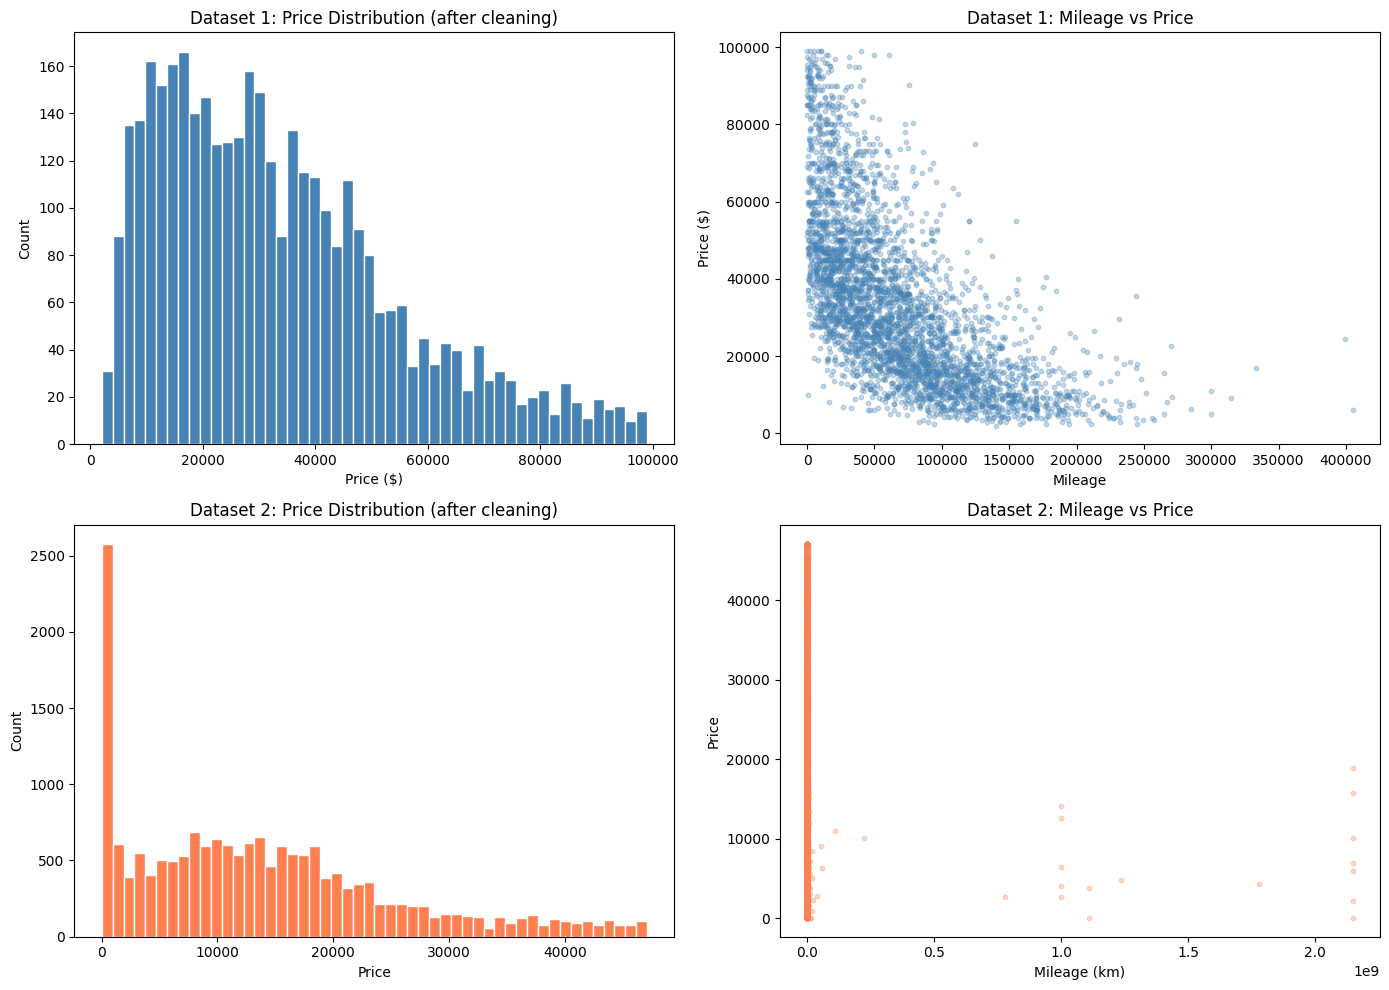

✅ บันทึกกราฟ eda_plots.png แล้ว


In [ ]:
# ============================================================
# CELL 6: Visualization — การกระจายของราคา
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dataset 1
axes[0, 0].hist(df1_clean['price'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Dataset 1: Price Distribution (after cleaning)')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].scatter(df1_clean['milage'], df1_clean['price'],
                   alpha=0.3, color='steelblue', s=10)
axes[0, 1].set_title('Dataset 1: Mileage vs Price')
axes[0, 1].set_xlabel('Mileage')
axes[0, 1].set_ylabel('Price ($)')

# Dataset 2
axes[1, 0].hist(df2_clean['Price'], bins=50, color='coral', edgecolor='white')
axes[1, 0].set_title('Dataset 2: Price Distribution (after cleaning)')
axes[1, 0].set_xlabel('Price')
axes[1, 0].set_ylabel('Count')

axes[1, 1].scatter(df2_clean['Mileage'], df2_clean['Price'],
                   alpha=0.3, color='coral', s=10)
axes[1, 1].set_title('Dataset 2: Mileage vs Price')
axes[1, 1].set_xlabel('Mileage (km)')
axes[1, 1].set_ylabel('Price')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึกกราฟ eda_plots.png แล้ว")

In [ ]:
# ============================================================
# CELL 7: Train/Test Split + Scaling
# ============================================================

# --- Dataset 1 ---
X1 = df1_encoded.drop(columns=['price'])
y1 = df1_encoded['price']
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled  = scaler1.transform(X1_test)

# --- Dataset 2 ---
X2 = df2_encoded.drop(columns=['Price'])
y2 = df2_encoded['Price']
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

print(f"✅ Dataset 1 — Train: {X1_train.shape}, Test: {X1_test.shape}")
print(f"✅ Dataset 2 — Train: {X2_train.shape}, Test: {X2_test.shape}")

✅ Dataset 1 — Train: (3012, 523), Test: (753, 523)
✅ Dataset 2 — Train: (14531, 105), Test: (3633, 105)


In [ ]:
# ============================================================
# CELL 8: โมเดลที่ 1 — Ensemble ML (Stacking Regressor)
# ประกอบด้วย: Random Forest + XGBoost + Ridge → Meta: Ridge
# ============================================================

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n📊 {name}")
    print(f"   MAE  : {mae:,.2f}")
    print(f"   RMSE : {rmse:,.2f}")
    print(f"   R²   : {r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# --- Base Models ---
base_models = [
    ('random_forest', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgboost',       XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)),
    ('ridge',         Ridge(alpha=1.0))
]

# --- Stacking Regressor Dataset 1 ---
print("🤖 เทรน Ensemble Dataset 1...")
stacking_model1 = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
stacking_model1.fit(X1_train_scaled, y1_train)
y1_pred_ensemble = stacking_model1.predict(X1_test_scaled)
results_ensemble_d1 = eval_model("Ensemble (Dataset 1 — used_cars)", y1_test, y1_pred_ensemble)

# --- Stacking Regressor Dataset 2 ---
print("\n🤖 เทรน Ensemble Dataset 2...")
stacking_model2 = StackingRegressor(
    estimators=[
        ('random_forest', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
        ('xgboost',       XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)),
        ('ridge',         Ridge(alpha=1.0))
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
stacking_model2.fit(X2_train_scaled, y2_train)
y2_pred_ensemble = stacking_model2.predict(X2_test_scaled)
results_ensemble_d2 = eval_model("Ensemble (Dataset 2 — car_price_prediction)", y2_test, y2_pred_ensemble)

# --- บันทึกโมเดล ---
joblib.dump(stacking_model1, 'ensemble_model_d1.pkl')
joblib.dump(stacking_model2, 'ensemble_model_d2.pkl')
joblib.dump(scaler1, 'scaler1.pkl')
joblib.dump(scaler2, 'scaler2.pkl')
joblib.dump(list(X1_train.columns), 'feature_columns_d1.pkl')
joblib.dump(list(X2_train.columns), 'feature_columns_d2.pkl')
print("\n✅ บันทึกโมเดล Ensemble เรียบร้อย")

🤖 เทรน Ensemble Dataset 1...

📊 Ensemble (Dataset 1 — used_cars)
   MAE  : 5,855.71
   RMSE : 8,724.12
   R²   : 0.8264

🤖 เทรน Ensemble Dataset 2...

📊 Ensemble (Dataset 2 — car_price_prediction)
   MAE  : 3,440.26
   RMSE : 5,649.03
   R²   : 0.7473

✅ บันทึกโมเดล Ensemble เรียบร้อย


In [ ]:
# ============================================================
# CELL 9: โมเดลที่ 2 — Neural Network (MLP)
# โครงสร้าง: Input → 256 → 128 → 64 → Output
# ============================================================

def build_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

# --- เทรน Dataset 1 ---
print("🧠 เทรน Neural Network Dataset 1...")
nn_model1 = build_nn(X1_train_scaled.shape[1])
nn_model1.summary()

history1 = nn_model1.fit(
    X1_train_scaled, y1_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y1_pred_nn = nn_model1.predict(X1_test_scaled).flatten()
results_nn_d1 = eval_model("Neural Network (Dataset 1 — used_cars)", y1_test, y1_pred_nn)

# --- เทรน Dataset 2 ---
print("\n🧠 เทรน Neural Network Dataset 2...")
nn_model2 = build_nn(X2_train_scaled.shape[1])

history2 = nn_model2.fit(
    X2_train_scaled, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

y2_pred_nn = nn_model2.predict(X2_test_scaled).flatten()
results_nn_d2 = eval_model("Neural Network (Dataset 2 — car_price_prediction)", y2_test, y2_pred_nn)

# --- บันทึกโมเดล ---
nn_model1.save('nn_model_d1.keras')
nn_model2.save('nn_model_d2.keras')
print("\n✅ บันทึกโมเดล Neural Network เรียบร้อย")

🧠 เทรน Neural Network Dataset 1...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       134,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,897 (691.00 KB)

 Trainable params: 176,129 (688.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1499809024.0000 - mae: 32363.3594 - val_loss: 1686297600.0000 - val_mae: 34726.8086
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1489313280.0000 - mae: 32293.3770 - val_loss: 1673243520.0000 - val_mae: 34577.6445
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1550617856.0000 - mae: 33120.3047 - val_loss: 1639384448.0000 - val_mae: 34168.7188
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1534579456.0000 - mae: 32833.0820 - val_loss: 1580646528.0000 - val_mae: 33423.4922
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1484584576.0000 - mae: 32190.1621 - val_loss: 1512396288.0000 - val_mae: 32676.5215
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1403590144.0000 - mae: 31390.3652 - val_loss: 1407696896.0000 - val_mae: 31344.2754
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1245242880.0000 - mae: 29231.2676 - val_loss: 1258195200.0000 - val_mae: 29339.9375

📊 สรุปผลการเปรียบเทียบโมเดล:


,Model,MAE,RMSE,R2
0,Ensemble (Dataset 1),5855.7063,8724.1194,0.8264
1,Neural Network (Dataset 1),19401.2934,24668.5041,-0.3883
2,Ensemble (Dataset 2),3440.2649,5649.0303,0.7473
3,Neural Network (Dataset 2),4853.8481,7040.7696,0.6075


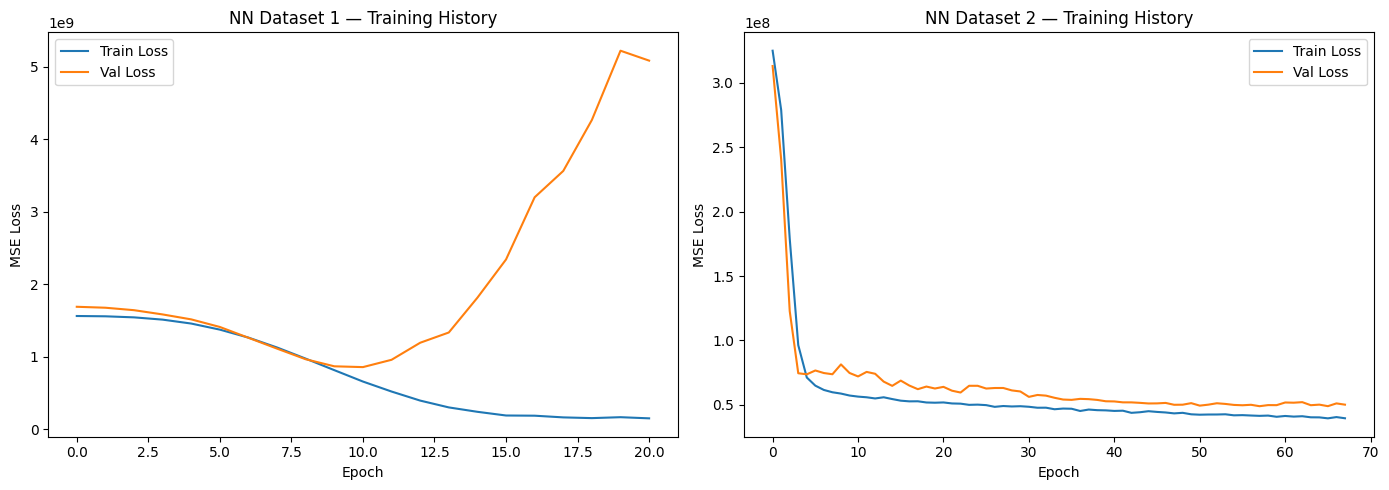

✅ บันทึกกราฟ training_history.png แล้ว


In [ ]:
# ============================================================
# CELL 10: เปรียบเทียบผลลัพธ์ทุกโมเดล
# ============================================================

results_df = pd.DataFrame({
    'Model': [
        'Ensemble (Dataset 1)',
        'Neural Network (Dataset 1)',
        'Ensemble (Dataset 2)',
        'Neural Network (Dataset 2)'
    ],
    'MAE':  [results_ensemble_d1['MAE'],  results_nn_d1['MAE'],
             results_ensemble_d2['MAE'],  results_nn_d2['MAE']],
    'RMSE': [results_ensemble_d1['RMSE'], results_nn_d1['RMSE'],
             results_ensemble_d2['RMSE'], results_nn_d2['RMSE']],
    'R2':   [results_ensemble_d1['R2'],   results_nn_d1['R2'],
             results_ensemble_d2['R2'],   results_nn_d2['R2']]
})

print("📊 สรุปผลการเปรียบเทียบโมเดล:")
display(results_df.round(4))

# Plot Training History ของ Neural Network
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['loss'], label='Train Loss')
axes[0].plot(history1.history['val_loss'], label='Val Loss')
axes[0].set_title('NN Dataset 1 — Training History')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(history2.history['loss'], label='Train Loss')
axes[1].plot(history2.history['val_loss'], label='Val Loss')
axes[1].set_title('NN Dataset 2 — Training History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึกกราฟ training_history.png แล้ว")

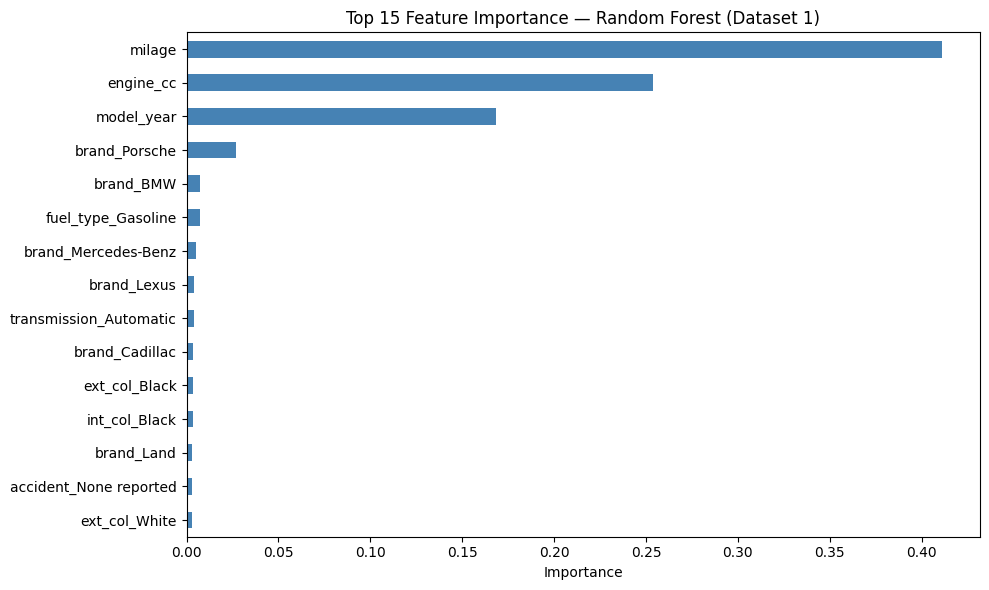

✅ บันทึกกราฟ feature_importance.png แล้ว

🎉 เสร็จสมบูรณ์! ไฟล์ที่บันทึกทั้งหมด:
  📦 ensemble_model_d1.pkl  — Ensemble model สำหรับ used_cars
  📦 ensemble_model_d2.pkl  — Ensemble model สำหรับ car_price_prediction
  🧠 nn_model_d1.keras      — Neural Network สำหรับ used_cars
  🧠 nn_model_d2.keras      — Neural Network สำหรับ car_price_prediction
  ⚖️  scaler1.pkl            — Scaler สำหรับ Dataset 1
  ⚖️  scaler2.pkl            — Scaler สำหรับ Dataset 2
  📋 feature_columns_d1.pkl — Feature names Dataset 1
  📋 feature_columns_d2.pkl — Feature names Dataset 2

➡️  ดาวน์โหลดไฟล์เหล่านี้ไว้ใช้กับ Streamlit Web App ต่อไป!


In [ ]:
# ============================================================
# CELL 11: Feature Importance + สรุปไฟล์ที่บันทึก
# ============================================================

# ดึง Feature Importance จาก Random Forest ใน Stacking (Dataset 1)
rf_estimator = stacking_model1.named_estimators_['random_forest']
feat_imp = pd.Series(
    rf_estimator.feature_importances_,
    index=X1_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importance — Random Forest (Dataset 1)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึกกราฟ feature_importance.png แล้ว")

print("\n🎉 เสร็จสมบูรณ์! ไฟล์ที่บันทึกทั้งหมด:")
print("  📦 ensemble_model_d1.pkl  — Ensemble model สำหรับ used_cars")
print("  📦 ensemble_model_d2.pkl  — Ensemble model สำหรับ car_price_prediction")
print("  🧠 nn_model_d1.keras      — Neural Network สำหรับ used_cars")
print("  🧠 nn_model_d2.keras      — Neural Network สำหรับ car_price_prediction")
print("  ⚖️  scaler1.pkl            — Scaler สำหรับ Dataset 1")
print("  ⚖️  scaler2.pkl            — Scaler สำหรับ Dataset 2")
print("  📋 feature_columns_d1.pkl — Feature names Dataset 1")
print("  📋 feature_columns_d2.pkl — Feature names Dataset 2")
print("\n➡️  ดาวน์โหลดไฟล์เหล่านี้ไว้ใช้กับ Streamlit Web App ต่อไป!")